<a href="https://colab.research.google.com/github/bhanuteja-29/Rain-prediction-using-Decision-Tree-and-Random-Forest-on-Australia-weather-Dataset-/blob/main/Decision_Trees_and_Random_Forests_Dec_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The following topics are covered in this tutorial:

- Downloading a real-world dataset
- Preparing a dataset for training
- Training and interpreting decision trees
- Training and interpreting random forests
- Overfitting, hyperparameter tuning & regularization
- Making predictions on single inputs


## Problem Statement

This tutorial takes a practical and coding-focused approach. We'll learn how to use _decision trees_ and _random forests_ to solve a real-world problem from [Kaggle](https://kaggle.com/datasets):

> **QUESTION**: The [Rain in Australia dataset](https://kaggle.com/jsphyg/weather-dataset-rattle-package) contains about 10 years of daily weather observations from numerous Australian weather stations. Here's a small sample from the dataset:
>
> ![](https://i.imgur.com/5QNJvir.png)
>
> As a data scientist at the Bureau of Meteorology, you are tasked with creating a fully-automated system that can use today's weather data for a given location to predict whether it will rain at the location tomorrow.
>
>
> ![](https://i.imgur.com/KWfcpcO.png)

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
raw_df = pd.read_csv("weatherAUS.csv")

In [153]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Let's drop any rows where the value of target column RainTomorrow is empty.

In [154]:
raw_df.dropna(subset=['RainTomorrow'],inplace=True)

## Preparing the Data for Training

We'll perform the following steps to prepare the dataset for training:

1. Create a train/test/validation split
2. Identify input and target columns
3. Identify numeric and categorical columns
4. Impute (fill) missing numeric values
5. Scale numeric values to the $(0, 1)$ range
6. Encode categorical columns to one-hot vectors

### Training, Validation and Test Sets

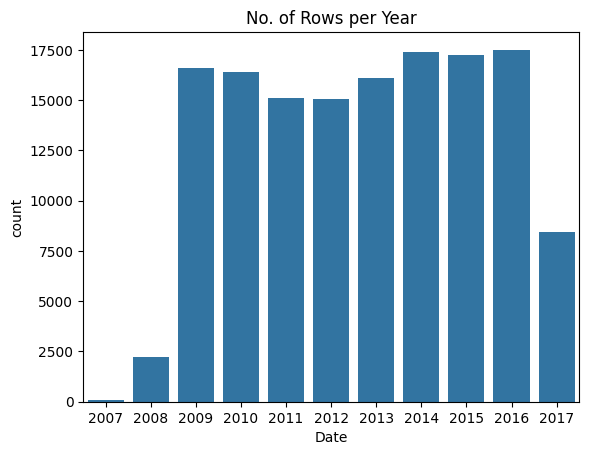

In [155]:
plt.title('No. of Rows per Year')
sns.countplot(x=pd.to_datetime(raw_df.Date).dt.year);

In [156]:
year = pd.to_datetime(raw_df.Date).dt.year

In [157]:
train_df,val_df,test_df = raw_df[year<2015],raw_df[year==2015],raw_df[year>2015]

In [158]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(98988, 23)
(17231, 23)
(25974, 23)


### Input and Target Columns

Let's identify the input and target columns.

In [159]:
#input columns exclude Date and RainTomorrow
input_cols = list(train_df.columns)[1:-1]
input_cols

['Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday']

In [160]:
target_cols = "RainTomorrow"

In [161]:
x_train = train_df[input_cols].copy()
y_train = train_df[target_cols].copy()

In [162]:
x_val = val_df[input_cols].copy()
y_val = val_df[target_cols].copy()

In [163]:
x_test = test_df[input_cols].copy()
y_test = test_df[target_cols].copy()

Let's also identify the numeric and categorical columns.

In [164]:
numeric_cols = x_train.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [165]:
categorical_cols = x_train.select_dtypes('object').columns.tolist()
categorical_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

### Imputing missing numeric values

In [166]:
from sklearn.impute import SimpleImputer

In [167]:
num_imputer = SimpleImputer(strategy='mean')

In [168]:
num_imputer.fit(x_train[numeric_cols])

SimpleImputer()

In [169]:
x_train[numeric_cols] = num_imputer.transform(x_train[numeric_cols])
x_val[numeric_cols] = num_imputer.transform(x_val[numeric_cols])
x_test[numeric_cols] = num_imputer.transform(x_test[numeric_cols])

In [170]:
cat_imputer = SimpleImputer(strategy='constant',fill_value='Unknown')
cat_imputer.fit(x_train[categorical_cols])

SimpleImputer(fill_value='Unknown', strategy='constant')

In [171]:
x_train[categorical_cols] = cat_imputer.transform(x_train[categorical_cols])
x_val[categorical_cols] = cat_imputer.transform(x_val[categorical_cols])
x_test[categorical_cols] = cat_imputer.transform(x_test[categorical_cols])

### Scaling Numeric Features

In [172]:
from sklearn.preprocessing import MinMaxScaler

In [173]:
scaler = MinMaxScaler()

In [174]:
scaler.fit(x_train[numeric_cols])

MinMaxScaler()

In [175]:
x_train[numeric_cols] = scaler.transform(x_train[numeric_cols])
x_val[numeric_cols] = scaler.transform(x_val[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

### Encoding Categorical Data

In [176]:
from sklearn.preprocessing import OneHotEncoder

In [177]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

In [178]:
encoder.fit(x_train[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [179]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [180]:

x_train[encoded_cols] = encoder.transform(x_train[categorical_cols])
x_val[encoded_cols] = encoder.transform(x_val[categorical_cols])
x_test[encoded_cols] = encoder.transform(x_test[categorical_cols])

/tmp/ipykernel_1136/362247944.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train[encoded_cols] = encoder.transform(x_train[categorical_cols])
/tmp/ipykernel_1136/362247944.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train[encoded_cols] = encoder.transform(x_train[categorical_cols])
/tmp/ipykernel_1136/362247944.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

As a final step, let's drop the textual categorical columns, so that we're left with just numeric data.

In [181]:
X_train = x_train[numeric_cols+encoded_cols]
X_val = x_val[numeric_cols+encoded_cols]
X_test = x_test[numeric_cols+encoded_cols]

In [182]:
X_test

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_Unknown,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_No,RainToday_Unknown,RainToday_Yes
2498,0.681604,0.798851,0.000000,0.064161,0.531618,0.372093,0.000000,0.080460,0.46,0.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2499,0.693396,0.722222,0.001078,0.064161,0.531618,0.341085,0.103448,0.195402,0.54,0.30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2500,0.634434,0.521073,0.005930,0.064161,0.531618,0.325581,0.126437,0.448276,0.62,0.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2501,0.608491,0.532567,0.042049,0.064161,0.531618,0.255814,0.103448,0.195402,0.74,0.65,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2502,0.566038,0.517241,0.018329,0.064161,0.531618,0.193798,0.068966,0.103448,0.92,0.63,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,0.283019,0.496169,0.000000,0.064161,0.531618,0.193798,0.172414,0.149425,0.59,0.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145455,0.266509,0.526820,0.000000,0.064161,0.531618,0.193798,0.149425,0.126437,0.51,0.24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145456,0.285377,0.563218,0.000000,0.064161,0.531618,0.124031,0.149425,0.103448,0.56,0.21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145457,0.327830,0.593870,0.000000,0.064161,0.531618,0.240310,0.103448,0.103448,0.53,0.24,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## Training and Visualizing Decision Trees

A decision tree in general parlance represents a hierarchical series of binary decisions:

<img src="https://i.imgur.com/qSH4lqz.png" width="480">

A decision tree in machine learning works in exactly the same way, and except that we let the computer figure out the optimal structure & hierarchy of decisions, instead of coming up with criteria manually.

### Training

We can use `DecisionTreeClassifier` from `sklearn.tree` to train a decision tree.

In [183]:
from sklearn.tree import DecisionTreeClassifier

In [184]:
model = DecisionTreeClassifier(random_state=42)

In [185]:
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

An optimal decision tree has now been created using the training data.

### Evaluation

Let's evaluate the decision tree using the accuracy score.

In [186]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [187]:
train_pred = model.predict(X_train)

In [188]:
accuracy_score(train_pred,y_train)

0.9999797955307714

In [189]:
test_pred = model.predict(X_test)
test_pred.size

25974

In [190]:
accuracy_score(model.predict(X_test),y_test)

0.7760837760837761

In [191]:
pd.Series(train_pred).value_counts()

,count
No,76707
Yes,22281


The training set accuracy is close to 100%! But we can't rely solely on the training set accuracy, we must evaluate the model on the validation set too.

We can make predictions and compute accuracy in one step using `model.score`

In [192]:
model.score(X_train,y_train)

0.9999797955307714

The decision tree also returns probabilities for each prediction.

In [193]:
train_probs = model.predict_proba(X_train)

In [194]:
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [195]:
val_pred = model.predict(X_val)
accuracy_score(y_val,val_pred)

0.7929893796065232

Although the training accuracy is 100%, the accuracy on the validation set is just about 79%, which is only marginally better then always predicting "No".

It appears that the model has learned the training examples perfect, and doesn't generalize well to previously unseen examples. This phenomenon is called "overfitting", and reducing overfitting is one of the most important parts of any machine learning project.

### Visualization

We can visualize the decision tree _learned_ from the training data.

In [196]:
from sklearn.tree import plot_tree,export_text

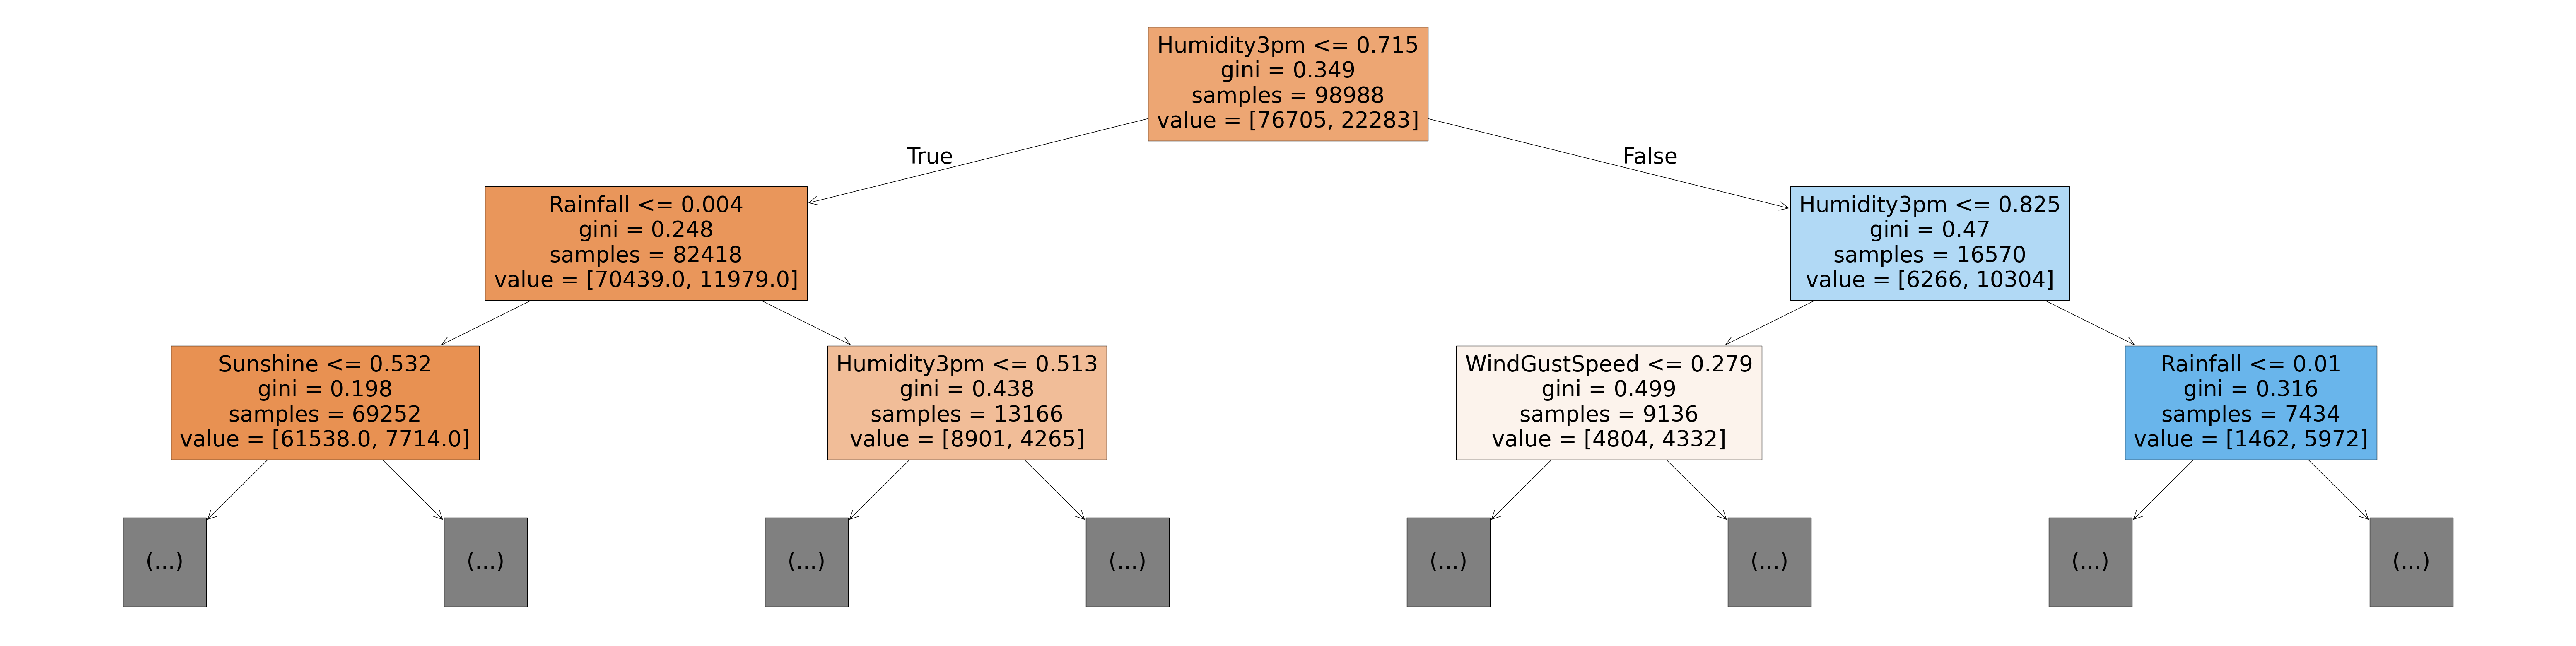

In [197]:
plt.figure(figsize=(80,20))
plot_tree(model,feature_names=X_train.columns,max_depth=2,filled=True);

Can you see how the model classifies a given input as a series of decisions? The tree is truncated here, but following any path from the root node down to a leaf will result in "Yes" or "No". Do you see how a decision tree differs from a logistic regression model?


**How a Decision Tree is Created**

Note the `gini` value in each box. This is the loss function used by the decision tree to decide which column should be used for splitting the data, and at what point the column should be split. A lower Gini index indicates a better split. A perfect split (only one class on each side) has a Gini index of 0.

For a mathematical discussion of the Gini Index, watch this video: https://www.youtube.com/watch?v=-W0DnxQK1Eo . It has the following formula:

<img src="https://i.imgur.com/CSC0gAo.png" width="240">

Conceptually speaking, while training the models evaluates all possible splits across all possible columns and picks the best one. Then, it recursively performs an optimal split for the two portions. In practice, however, it's very inefficient to check all possible splits, so the model uses a heuristic (predefined strategy) combined with some randomization.

The iterative approach of the machine learning workflow in the case of a decision tree involves growing the tree layer-by-layer:

<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">


Let's check the depth of the tree that was created.

In [198]:
model.tree_.max_depth

48

### Feature Importance

Based on the gini index computations, a decision tree assigns an "importance" value to each feature. These values can be used to interpret the results given by a decision tree.

In [199]:
model.feature_importances_

array([3.59693809e-02, 3.12813242e-02, 5.85936415e-02, 2.27964832e-02,
       4.94950179e-02, 5.53301667e-02, 2.85301029e-02, 3.12159266e-02,
       3.88292210e-02, 2.61880735e-01, 3.42357497e-02, 6.14596462e-02,
       1.37900267e-02, 1.75962179e-02, 3.41056992e-02, 2.98176014e-02,
       2.07817897e-03, 2.14987613e-03, 1.50143313e-03, 6.40117134e-04,
       1.58888448e-03, 1.11721152e-03, 7.00504227e-04, 1.77002115e-03,
       1.33809912e-03, 1.51957686e-03, 8.83429996e-04, 2.39168857e-03,
       1.68951308e-03, 2.05586876e-04, 1.14392097e-03, 1.65496962e-03,
       5.03399284e-04, 8.17173668e-04, 1.36128777e-03, 8.97854563e-04,
       1.03752527e-03, 7.44440460e-04, 1.78286516e-03, 2.05734177e-03,
       2.72778717e-04, 6.32810071e-04, 1.47394157e-03, 1.35126933e-03,
       1.33826758e-03, 9.17956348e-04, 6.13692039e-04, 1.46476875e-03,
       1.17135375e-03, 2.01909430e-03, 9.64454318e-04, 1.80419066e-03,
       1.09569479e-03, 1.15531312e-03, 1.24389290e-03, 5.12884974e-04,
      

Let's turn this into a dataframe and visualize the most important features.

In [200]:
importance_df = pd.DataFrame({
    "Feature" : X_train.columns,
    "Importance_Value" : model.feature_importances_
}).sort_values('Importance_Value',ascending=False)

In [201]:
importance_df.head(10)

,Feature,Importance_Value
9,Humidity3pm,0.261881
11,Pressure3pm,0.061460
2,Rainfall,0.058594
5,WindGustSpeed,0.055330
4,Sunshine,0.049495
8,Humidity9am,0.038829
0,MinTemp,0.035969
10,Pressure9am,0.034236
14,Temp9am,0.034106
1,MaxTemp,0.031281


<Axes: xlabel='Importance_Value', ylabel='Feature'>

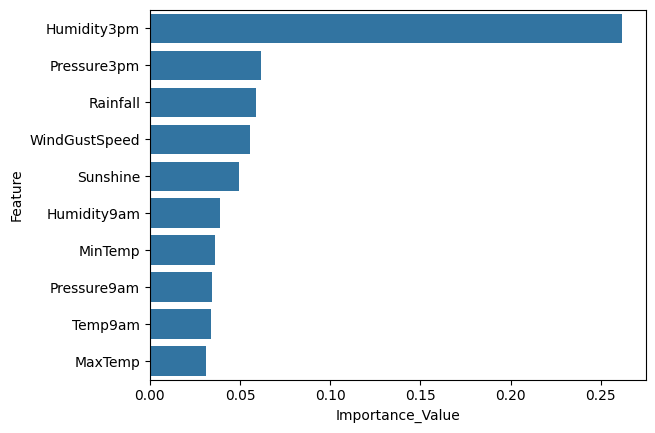

In [202]:
sns.barplot(data=importance_df.head(10),x='Importance_Value',y="Feature")

## Hyperparameter Tuning and Overfitting

As we saw in the previous section, our decision tree classifier memorized all training examples, leading to a 100% training accuracy, while the validation accuracy was only marginally better than a dumb baseline model. This phenomenon is called overfitting, and in this section, we'll look at some strategies for reducing overfitting.

The `DecisionTreeClassifier` accepts several arguments, some of which can be modified to reduce overfitting.

These arguments are called hyperparameters because they must be configured manually (as opposed to the parameters within the model which are _learned_ from the data. We'll explore a couple of hyperparameters:

- `max_depth`
- `max_leaf_nodes`

### `max_depth`

By reducing the maximum depth of the decision tree, we can prevent the tree from memorizing all training examples, which may lead to better generalization

In [203]:
model = DecisionTreeClassifier(max_depth=3,random_state=42)

In [204]:
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [205]:
train_pred = model.predict(X_train)

In [206]:
accuracy_score(y_train,train_pred)

0.8291308037337859

In [207]:
val_pred = model.predict(X_val)
accuracy_score(y_val,val_pred)

0.8334397307178921

Great, while the training accuracy of the model has gone down, the validation accuracy of the model has increased significantly.

In [208]:
model.classes_

array(['No', 'Yes'], dtype=object)

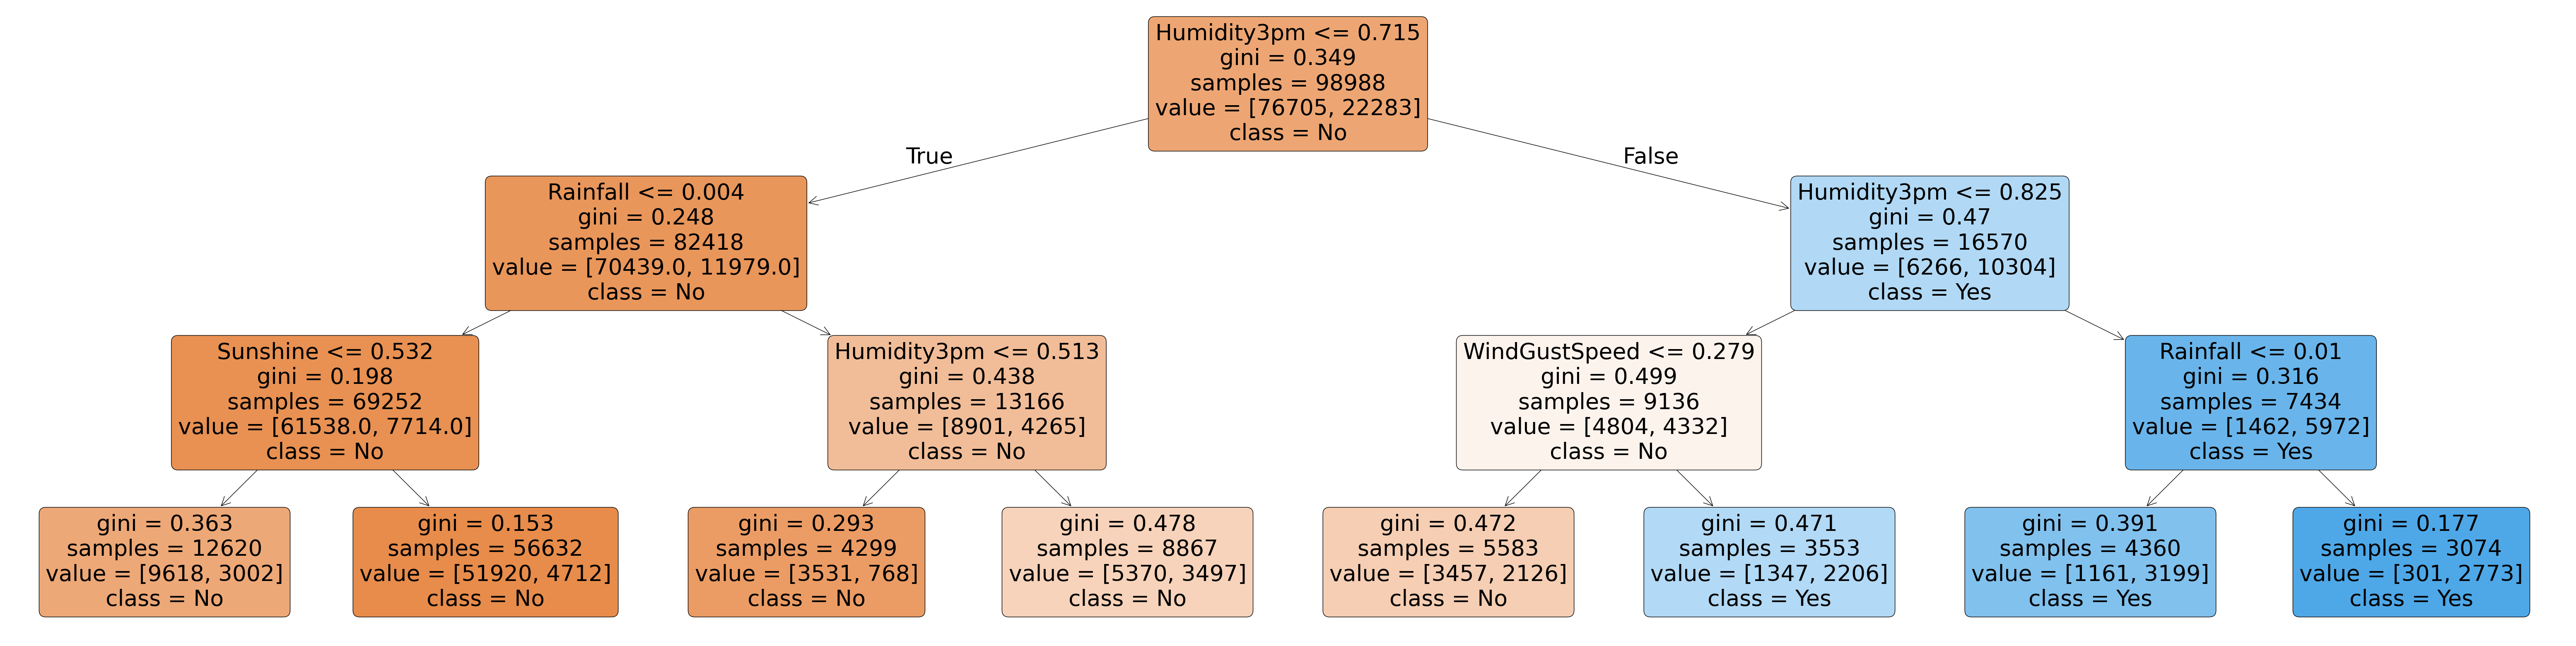

In [209]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

Let's experiment with different depths using a helper function.

In [210]:
def max_depth_error(md):
  model = DecisionTreeClassifier(max_depth=md,random_state=42)
  model.fit(X_train,y_train)
  train_error_pct = (1-model.score(X_train,y_train))*100
  val_error_pct = (1-model.score(X_val,y_val))*100
  return {'Max Depth':md,"Training Error_pct":train_error_pct,"Validation Error_pct":val_error_pct}




In [211]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: user 46 s, sys: 1.23 s, total: 47.2 s
Wall time: 47.6 s


In [212]:
errors_df.sort_values(by='Validation Error_pct')

,Max Depth,Training Error_pct,Validation Error_pct
6,7,15.331151,15.460507
8,9,14.096658,15.663630
9,10,13.299592,15.721664
5,6,15.627147,15.727468
7,8,14.780579,15.797110
10,11,12.322706,15.866752
4,5,16.067604,15.907376
11,12,11.319554,16.197551
12,13,10.179012,16.406477
3,4,16.570695,16.435494


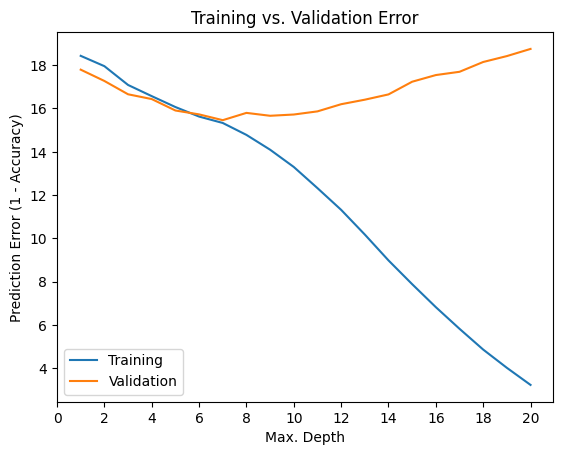

In [213]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error_pct'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error_pct'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

This is a common pattern you'll see with all machine learning algorithms:

<img src="https://i.imgur.com/EJCrSZw.png" width="480">




In [214]:
model = DecisionTreeClassifier(max_depth=7,random_state=42).fit(X_train,y_train)
model.score(X_val,y_val)


0.8453949277465034

You'll often need to tune hyperparameters carefully to find the optimal fit. In the above case, it appears that a maximum depth of 7 results in the lowest validation error.

### `max_leaf_nodes`

Another way to control the size of complexity of a decision tree is to limit the number of leaf nodes. This allows branches of the tree to have varying depths.

In [215]:
model = DecisionTreeClassifier(max_leaf_nodes=128,random_state=42)

In [216]:
model.fit(X_train,y_train)

DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [217]:
model.score(X_train,y_train)

0.8480421869317493

In [218]:
model.score(X_val, y_val)

0.8442342290058615

In [219]:
model.tree_.max_depth

12

Notice that the model was able to achieve a greater depth of 12 for certain paths while keeping other paths shorter.

> **EXERCISE**: Find the combination of `max_depth` and `max_leaf_nodes` that results in the highest validation accuracy.

In [220]:
md = 7
max_leaf = 120
model = DecisionTreeClassifier(max_leaf_nodes=max_leaf,random_state=42,max_depth=md)
model.fit(X_train,y_train)
model.score(X_val,y_val)

0.8454529626835355

## Training a Random Forest

While tuning the hyperparameters of a single decision tree may lead to some improvements, a much more effective strategy is to combine the results of several decision trees trained with slightly different parameters. This is called a random forest.

The key idea here is that each decision tree in the forest will make different kinds of errors, and upon averaging, many of their errors will cancel out. This idea is also known as the "wisdom of the crowd" in common parlance:

<img src="https://i.imgur.com/4Dg0XK4.png" width="480">

A random forest works by averaging/combining the results of several decision trees:

<img src="https://1.bp.blogspot.com/-Ax59WK4DE8w/YK6o9bt_9jI/AAAAAAAAEQA/9KbBf9cdL6kOFkJnU39aUn4m8ydThPenwCLcBGAsYHQ/s0/Random%2BForest%2B03.gif" width="640">


We'll use the `RandomForestClassifier` class from `sklearn.ensemble`.

In [221]:
from sklearn.ensemble import RandomForestClassifier

In [222]:
model = RandomForestClassifier(n_jobs=-1,random_state=42)

n_jobs allows the random forest to use multiple parallel workers to train decision trees, and random_state=42 ensures that we get the same results for each execution

In [223]:
%%time
model.fit(X_train, y_train)

CPU times: user 47.6 s, sys: 329 ms, total: 47.9 s
Wall time: 29.5 s


RandomForestClassifier(n_jobs=-1, random_state=42)

In [224]:
model.score(X_train,y_train)

0.9999595910615429

In [225]:
model.score(X_val,y_val)

0.8562474609715048

Once again, the training accuracy is 100%, but this time the validation accuracy is much better. In fact, it is better than the best single decision tree we had trained so far. Do you see the power of random forests?

This general technique of combining the results of many models is called "ensembling", it works because most errors of individual models cancel out on averaging. Here's what it looks like visually:

<img src="https://i.imgur.com/qJo8D8b.png" width="480">


We can also look at the probabilities for the predictions. The probability of a class is simply the fraction of trees which that predicted the given class.

In [226]:
train_pred = model.predict(X_train)
train_pred

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [227]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.93, 0.07],
       [0.96, 0.04],
       [0.98, 0.02],
       ...,
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.96, 0.04]])

We can access individual decision trees using model.estimators_

In [228]:
model.estimators_[0]

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)

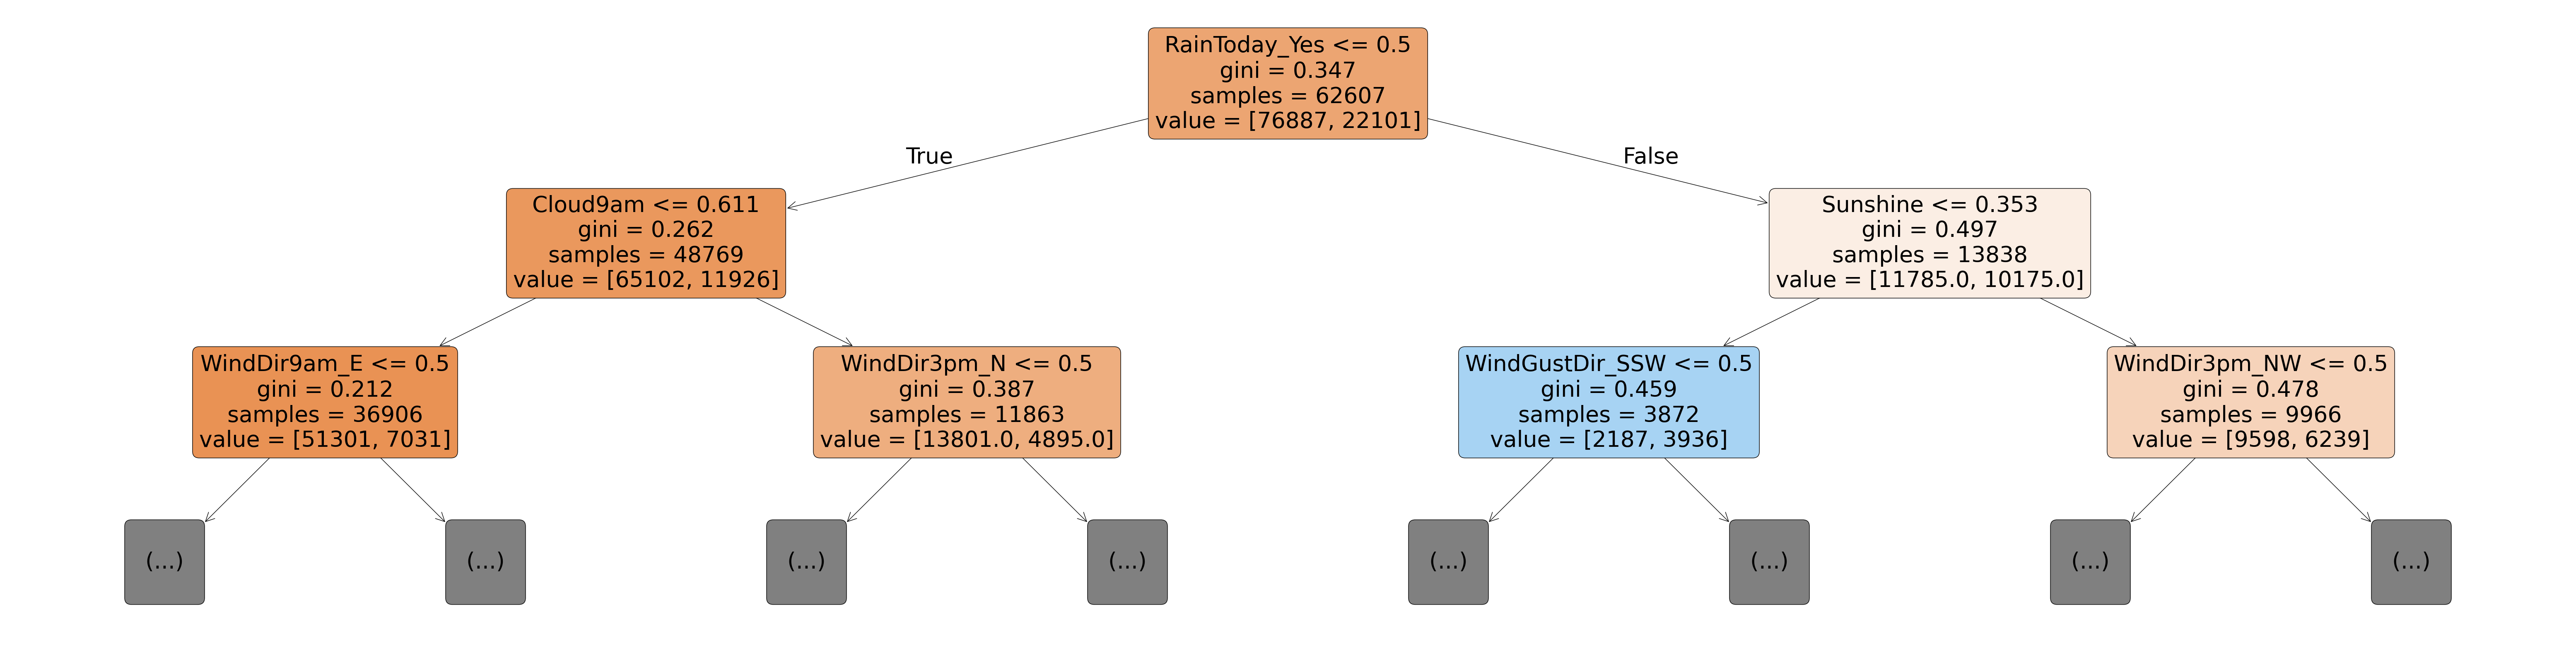

In [229]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[0],max_depth=2,feature_names=X_train.columns,filled=True,rounded=True);

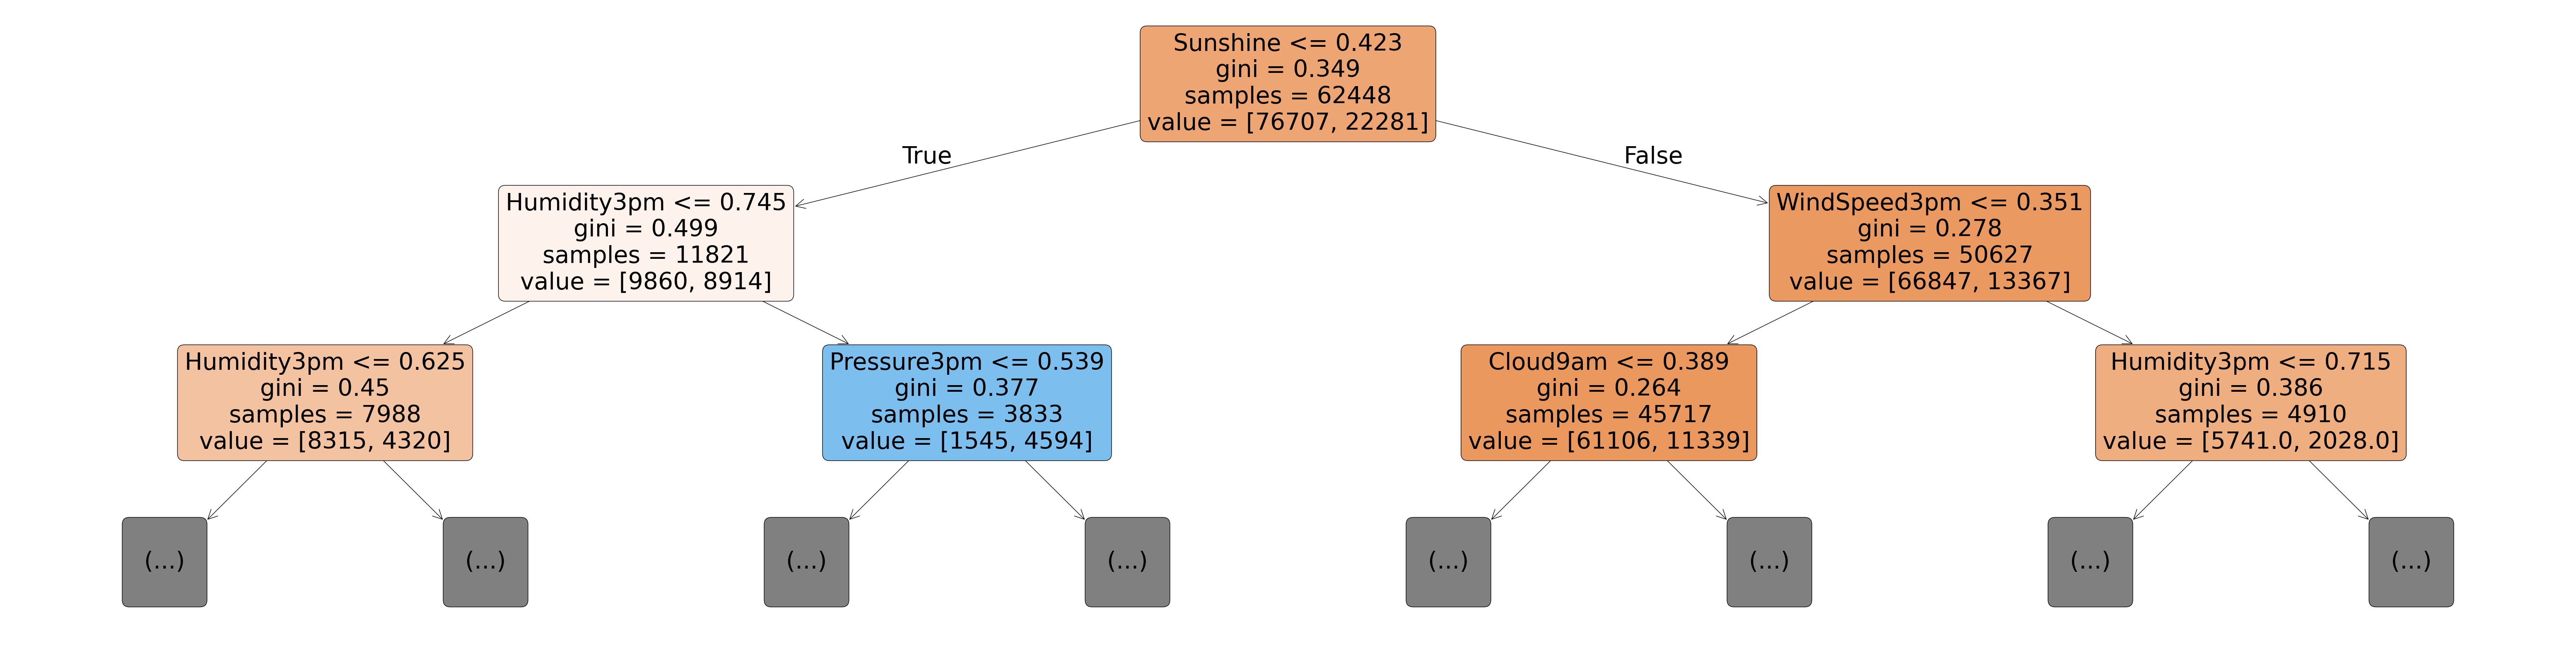

In [230]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[15],max_depth=2,feature_names=X_train.columns,filled=True,rounded=True);

> **EXERCISE**: Verify that none of the individual decision trees have a better validation accuracy than the random forest.

Just like decision tree, random forests also assign an "importance" to each feature, by combining the importance values from individual trees.

In [231]:
importance_df = pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':model.feature_importances_
}).sort_values('Importance',ascending=False)

In [232]:
importance_df.head()

,Feature,Importance
9,Humidity3pm,0.136243
11,Pressure3pm,0.053763
4,Sunshine,0.053188
8,Humidity9am,0.049222
10,Pressure9am,0.048689


<Axes: xlabel='Importance', ylabel='Feature'>

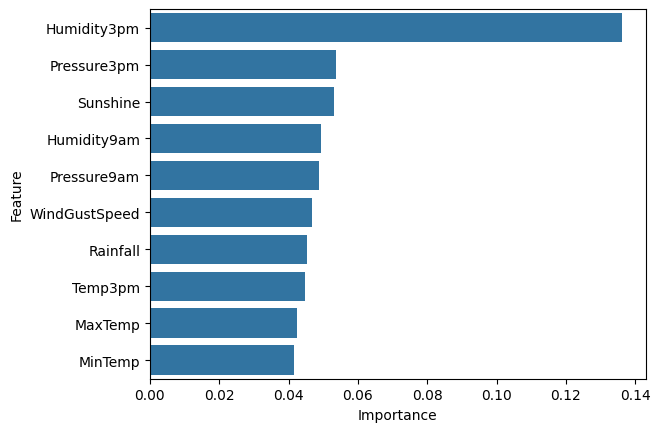

In [233]:
sns.barplot(data=importance_df.head(10),x="Importance",y="Feature")

## Hyperparameter Tuning with Random Forests

Just like decision trees, random forests also have several hyperparameters. In fact many of these hyperparameters are applied to the underlying decision trees.

Let's study some the hyperparameters for random forests. You can learn more about them here: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Let's create a base model with which we can compare models with tuned hyperparameters

In [234]:
base_model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train,y_train)

In [235]:
base_train_acc = base_model.score(X_train,y_train)
base_val_acc = base_model.score(X_val,y_val)

In [236]:
base_acc = base_train_acc,base_val_acc
base_acc

(0.9999595910615429, 0.8562474609715048)

We can use this as a benchmark for hyperparameter tuning


### `n_estimators`

This controls the number of decision trees in the random forest. The default value is 100. For larger datasets, it helps to have a greater number of estimators. As a general rule, try to have as few estimators as needed.



In [237]:
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=65)

In [238]:
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=65, n_jobs=-1, random_state=42)

In [239]:
model.score(X_train, y_train), model.score(X_val, y_val)

(0.9998888754192428, 0.8566537055307295)

### `max_depth` and `max_leaf_nodes`

These arguments are passed directly to each decision tree, and control the maximum depth and max. no leaf nodes of each tree respectively. By default, no maximum depth is specified, which is why each tree has a training accuracy of 100%. You can specify a `max_depth` to reduce overfitting.

<img src="https://i.imgur.com/EJCrSZw.png" width="480">

Let's define a helper function to `max depth`, `max_leaf_nodes` and other hyperparameters easily.

In [240]:
def test_params(**params):
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params).fit(X_train, y_train)
    return model.score(X_train, y_train), model.score(X_val, y_val)

Let's test a few values of `max_depth`.

In [241]:
test_params(max_depth=30)

(0.9939689659352648, 0.8558412164122802)

In [242]:
test_params(max_leaf_nodes=2**5)

(0.8300096981452297, 0.832046892229122)

In [243]:
base_acc

(0.9999595910615429, 0.8562474609715048)

The optimal values of `max_depth` and `max_leaf_nodes` lies somewhere between 0 and unbounded.

### `max_features`

Instead of picking all features for every split, we can specify only a fraction of features to be chosen randomly.

<img src="https://i.imgur.com/FXGWMDY.png" width="720">

Notice that the default value `auto` causes only $\sqrt{n}$ out of total features ( $n$ ) to be chosen randomly at each split. This is the reason each decision tree is in the forest is different. While it may seem counterintuitive, choosing all features for every split of every tree will lead to identical trees, so the random forest will not generalize well.

In [244]:
test_params(max_features='log2')

(0.9999393865923142, 0.855144797167895)

### `min_samples_split` and `min_samples_leaf`

By default, the decision tree classifier tries to split every node that has 2 or more. You can increase the values of these arguments to change this behavior and reduce overfitting, especially for very large datasets.

In [245]:
test_params(min_samples_split=3, min_samples_leaf=2)

(0.9619347799733301, 0.8560153212233764)

In [246]:
test_params(min_samples_split=100, min_samples_leaf=60)

(0.8494868064815937, 0.8453949277465034)

In [247]:
base_acc

(0.9999595910615429, 0.8562474609715048)

### `min_impurity_decrease`

This argument is used to control the threshold for splitting nodes. A node will be split if this split induces a decrease of the impurity (Gini index) greater than or equal to this value. It's default value is 0, and you can increase it to reduce overfitting.


In [248]:
test_params(min_impurity_decrease=1e-6)

(0.9889784620358023, 0.8564215657826011)

In [249]:
base_acc

(0.9999595910615429, 0.8562474609715048)

### `bootstrap`, `max_samples`

By default, a random forest doesn't use the entire dataset for training each decision tree. Instead it applies a technique called bootstrapping. For each tree, rows from the dataset are picked one by one randomly, with replacement i.e. some rows may not show up at all, while some rows may show up multiple times.


<img src="https://i.imgur.com/W8UGaEA.png" width="640">

Bootstrapping helps the random forest generalize better, because each decision tree only sees a fraction of th training set, and some rows randomly get higher weightage than others.

In [250]:
test_params(bootstrap=False)

(0.9999797955307714, 0.8564796007196332)

In [251]:
base_acc

(0.9999595910615429, 0.8562474609715048)

When bootstrapping is enabled, you can also control the number or fraction of rows to be considered for each bootstrap using `max_samples`. This can further generalize the model.

<img src="https://i.imgur.com/rsdrL1W.png" width="640">

In [252]:
test_params(max_samples=0.9)

(0.9997676486038711, 0.8565376356566653)

### `class_weight`

In [253]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [254]:
test_params(class_weight='balanced')

(0.9999494888269285, 0.8548546224827346)

In [255]:
test_params(class_weight={'No':1,'Yes':2})

(0.9999595910615429, 0.8553769369160235)